# 🌱 AI-Powered Soil Analytics for Crop Management

### Milestone 2: Machine Learning, Explainable AI & Hybrid Analysis

This notebook implements soil image classification using ResNet50 Transfer Learning, structured crop recommendation using Random Forest, Grad-CAM explainability, and hybrid analysis combining image and structured data.

## 🎯 Milestone 2 Objectives

The main objectives of Milestone 2 are:

1. Perform soil image classification using a CNN-based transfer learning model.
2. Train and evaluate a ResNet50 model for soil type prediction.
3. Analyze model performance using accuracy, precision, recall, F1-score and confusion matrix.
4. Analyze incorrect predictions.
5. Apply Grad-CAM for model explainability.
6. Train a structured machine learning model for crop recommendation.
7. Combine image-based soil classification and structured data analysis using a hybrid approach.

## 1. Connect Google Drive

The soil image dataset is stored in Google Drive. Google Drive is mounted in Google Colab so that the image dataset can be accessed during model training and evaluation.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully! ✅")

Mounted at /content/drive
Google Drive connected successfully! ✅


## 2. Soil Image Dataset

In [3]:
import os

dataset_path = "/content/drive/MyDrive/Orignal-Dataset"

print("Dataset exists:", os.path.exists(dataset_path))
print("Soil classes:", os.listdir(dataset_path))

Dataset exists: True
Soil classes: ['Arid_Soil', 'Mountain_Soil', 'Alluvial_Soil', 'Yellow_Soil', 'Laterite_Soil', 'Red_Soil', 'Black_Soil']


In [4]:
total_images = 0

for soil_class in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, soil_class)

    count = sum(
        1 for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    )

    total_images += count
    print(f"{soil_class}: {count} images")

print("\nTotal images:", total_images)

Alluvial_Soil: 51 images
Arid_Soil: 300 images
Black_Soil: 255 images
Laterite_Soil: 219 images
Mountain_Soil: 201 images
Red_Soil: 129 images
Yellow_Soil: 69 images

Total images: 1224


## 3. Dataset Splitting

In [5]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 1224 files belonging to 7 classes.
Using 857 files for training.
Found 1224 files belonging to 7 classes.
Using 367 files for validation.
Classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


In [6]:
val_ds = temp_ds.take(6)
test_ds = temp_ds.skip(6)

print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Validation batches: 6
Test batches: 6


## 4. Visualize Sample Images


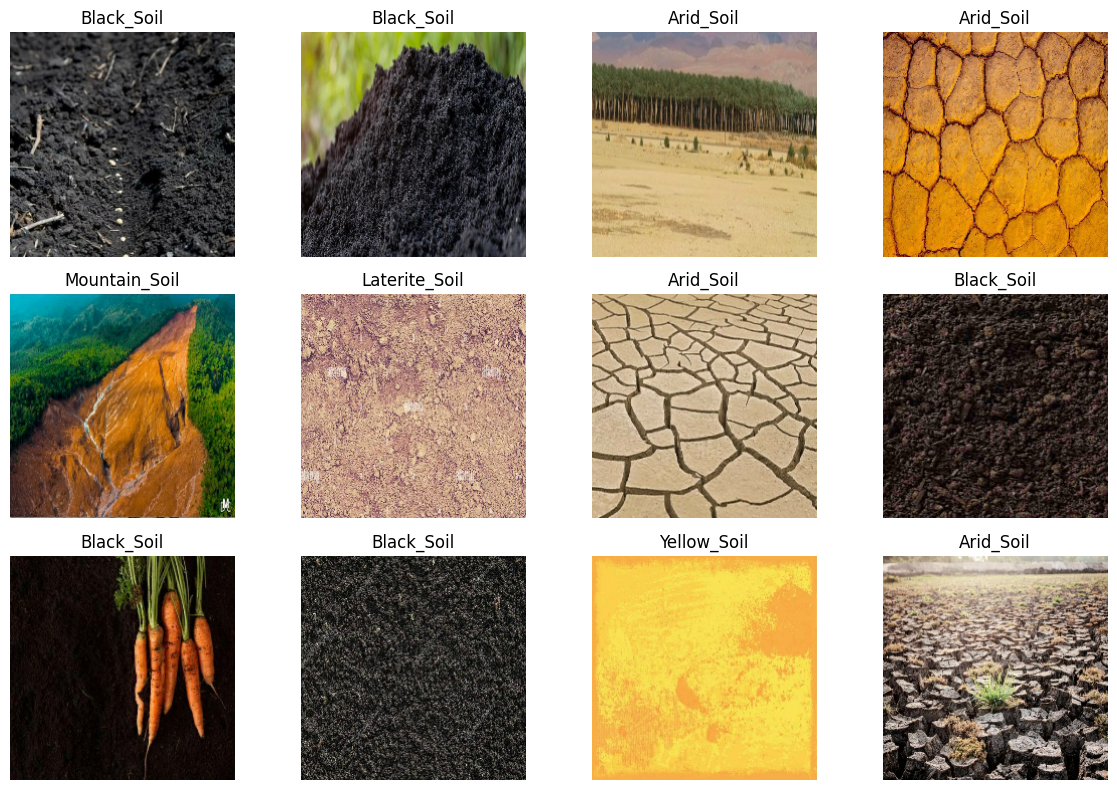

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Data Augmentation

In [8]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

print("Data augmentation created successfully! ✅")

Data augmentation created successfully! ✅


## 6. ResNet50 Transfer Learning


In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation="softmax")
])

print("ResNet50 model created successfully! ✅")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 model created successfully! ✅


## 7. Model Compilation

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully! ✅")

Model compiled successfully! ✅


In [11]:
from PIL import Image
import os

file_path = "/content/drive/MyDrive/Orignal-Dataset/Black_Soil/157a.jpg"

print("File exists:", os.path.exists(file_path))

try:
    img = Image.open(file_path)
    img.verify()
    print("Image is readable! ✅")
except Exception as e:
    print("Image error:", e)

File exists: True
Image is readable! ✅


In [12]:
# Test one batch before full training

for images, labels in train_ds.take(1):
    output = model(images, training=False)

print("One training batch processed successfully! ✅")
print("Output shape:", output.shape)

One training batch processed successfully! ✅
Output shape: (32, 7)


## 8. Model Training

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 225s 8s/step - accuracy: 0.2835 - loss: 2.0651 - val_accuracy: 0.3750 - val_loss: 1.6782
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 204s 8s/step - accuracy: 0.5286 - loss: 1.3768 - val_accuracy: 0.6198 - val_loss: 1.1644
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 259s 8s/step - accuracy: 0.6453 - loss: 1.0800 - val_accuracy: 0.6979 - val_loss: 1.0149
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 204s 8s/step - accuracy: 0.7398 - loss: 0.8342 - val_accuracy: 0.7760 - val_loss: 0.7475
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 195s 7s/step - accuracy: 0.7655 - loss: 0.7388 - val_accuracy: 0.7552 - val_loss: 0.7352
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 203s 8s/step - accuracy: 0.8168 - loss: 0.5926 - val_accuracy: 0.7448 - val_loss: 0.7046
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 202s 8s/step - accuracy: 0.8261 - loss: 0.5389 - val_accuracy: 0.7760 - val_loss: 0.6101
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 203s 8s/step - accuracy: 0.8425 - loss: 0.5240 - val_accuracy: 0.7708 - v

## 9. Model Evaluation


In [14]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.8171 - loss: 0.5340
Test Loss: 0.5339757204055786
Test Accuracy: 0.8171428442001343


## 10. Classification Report

In [16]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

               precision    recall  f1-score   support

Alluvial_Soil       0.00      0.00      0.00        11
    Arid_Soil       0.76      0.94      0.84        36
   Black_Soil       0.94      0.97      0.95        30
Laterite_Soil       0.65      0.97      0.78        31
Mountain_Soil       0.96      0.84      0.90        32
     Red_Soil       0.95      0.79      0.86        24
  Yellow_Soil       1.00      0.45      0.62        11

     accuracy                           0.82       175
    macro avg       0.75      0.71      0.71       175
 weighted avg       0.80      0.82      0.80       175



## 11. Confusion Matrix

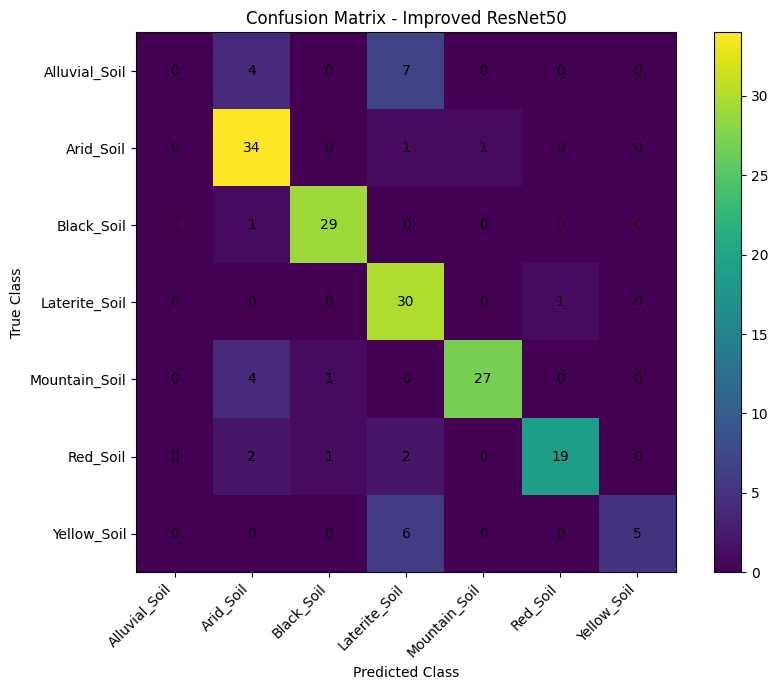

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)

plt.title("Confusion Matrix - Improved ResNet50")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [18]:
model.save("/content/drive/MyDrive/resnet50_soil_model_improved.keras")

print("Improved ResNet50 model saved successfully! ✅")

Improved ResNet50 model saved successfully! ✅


## 12. Incorrect Prediction Analysis

In [19]:
import matplotlib.pyplot as plt

wrong_indices = np.where(y_true != y_pred)[0]

print("Total test images:", len(y_true))
print("Incorrect predictions:", len(wrong_indices))
print("Correct predictions:", len(y_true) - len(wrong_indices))

Total test images: 175
Incorrect predictions: 31
Correct predictions: 144


## 13. Explainable AI using Grad-CAM

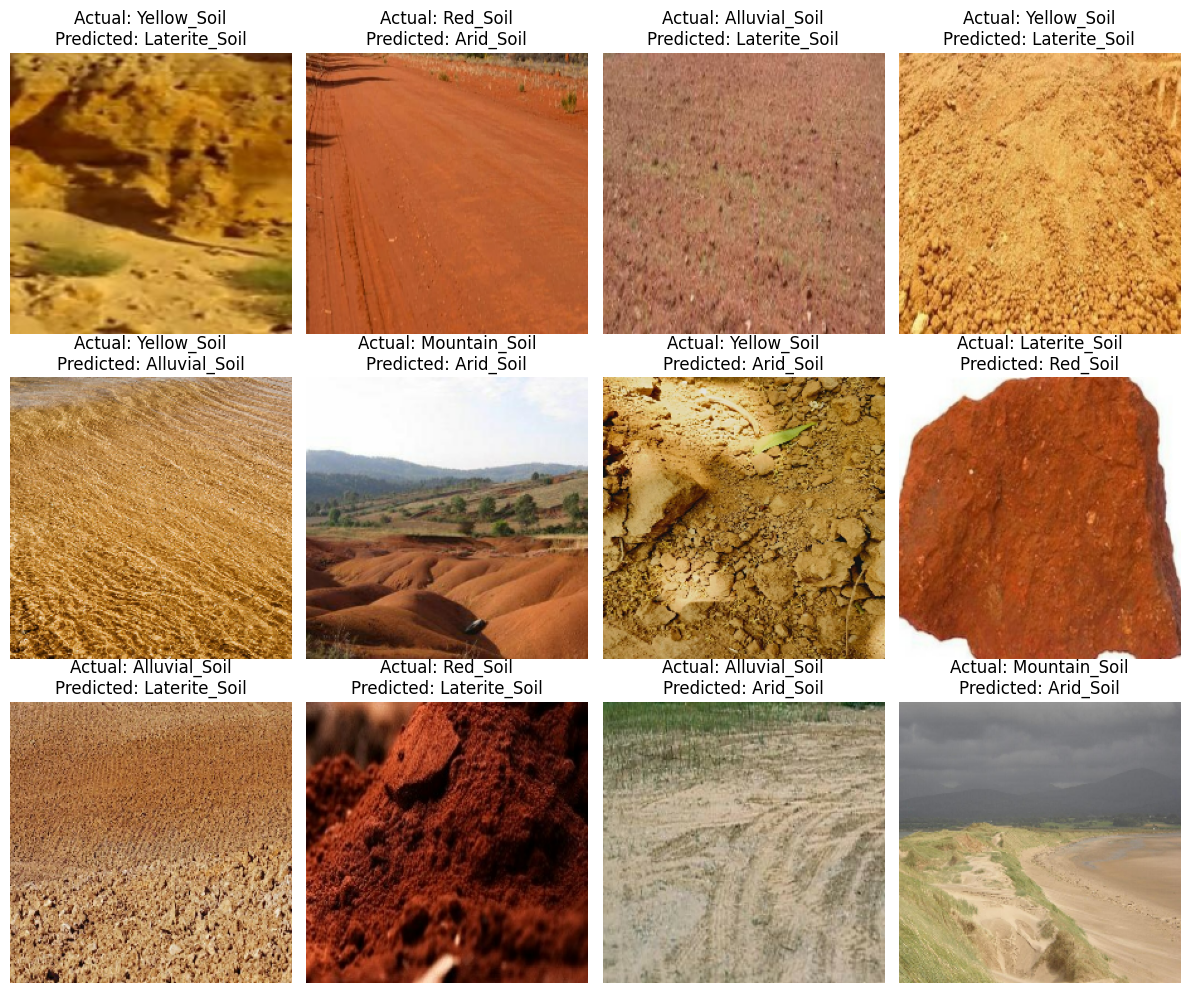

In [20]:
import matplotlib.pyplot as plt
import os

wrong_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12, 10))

shown = 0

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    for i in range(len(images)):
        if shown >= 12:
            break

        actual = labels[i].numpy()
        predicted = np.argmax(predictions[i])

        if actual != predicted:
            ax = plt.subplot(3, 4, shown + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(
                f"Actual: {class_names[actual]}\n"
                f"Predicted: {class_names[predicted]}"
            )
            plt.axis("off")
            shown += 1

    if shown >= 12:
        break

plt.tight_layout()
plt.show()

In [21]:
# Find the last convolutional layer in ResNet50

for layer in reversed(base_model.layers):
    if len(layer.output.shape) == 4:
        print("Last convolutional layer:", layer.name)
        break

Last convolutional layer: conv5_block3_out


In [23]:
# Make sure the model has a defined input/output graph
dummy_input = tf.zeros((1, 224, 224, 3))
_ = model(dummy_input, training=False)

print("Model graph initialized successfully! ✅")

Model graph initialized successfully! ✅


In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Get one test image
for images, labels in test_ds.take(1):
    image = images[0]
    true_label = int(labels[0].numpy())

input_image = tf.expand_dims(image, axis=0)

# Get the ResNet50 base model
resnet_base = model.layers[2]

# Build a Grad-CAM model using the trained layers
grad_model = tf.keras.Model(
    inputs=resnet_base.input,
    outputs=[
        resnet_base.get_layer("conv5_block3_out").output,
        resnet_base.output
    ]
)

# Preprocess the image exactly as ResNet50 expects
processed_image = tf.keras.applications.resnet50.preprocess_input(
    tf.cast(input_image, tf.float32)
)

# Calculate gradients
with tf.GradientTape() as tape:
    conv_outputs, feature_output = grad_model(processed_image)

    x = model.layers[3](feature_output)
    x = model.layers[4](x)
    x = model.layers[5](x)
    x = model.layers[6](x)
    x = model.layers[7](x)

    predictions = x
    predicted_label = tf.argmax(predictions[0])

    class_score = predictions[:, predicted_label]

grads = tape.gradient(class_score, conv_outputs)

print("Gradient calculated:", grads is not None)

Gradient calculated: True


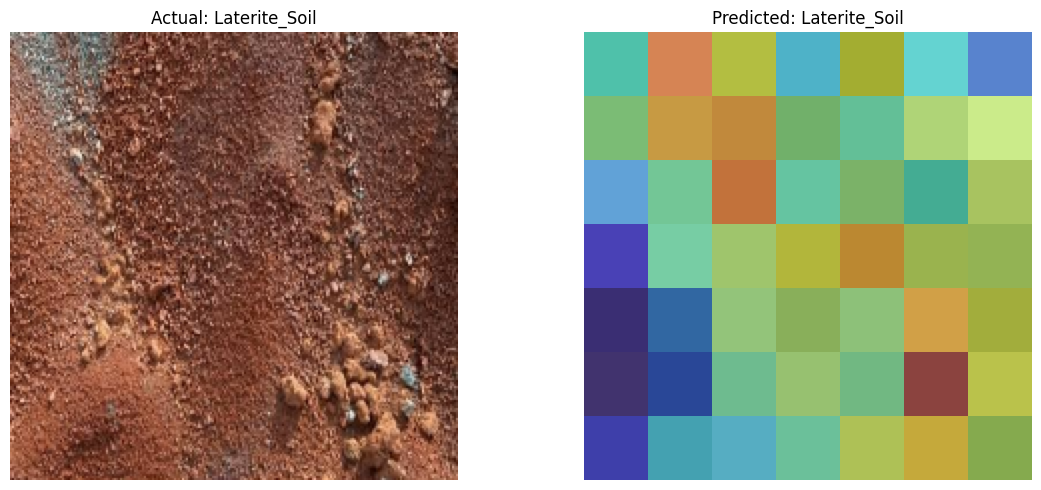

In [28]:
# Generate Grad-CAM heatmap

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

# Normalize heatmap
heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

# Display original image and Grad-CAM
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.numpy().astype("uint8"))
plt.title(f"Actual: {class_names[true_label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image.numpy().astype("uint8"))
plt.imshow(
    heatmap.numpy(),
    cmap="jet",
    alpha=0.5
)
plt.title(
    f"Predicted: {class_names[int(predicted_label)]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
plt.savefig(
    "/content/drive/MyDrive/GradCAM_Laterite_Soil.png",
    bbox_inches="tight"
)

print("Grad-CAM result saved successfully! ✅")

Grad-CAM result saved successfully! ✅


<Figure size 640x480 with 0 Axes>

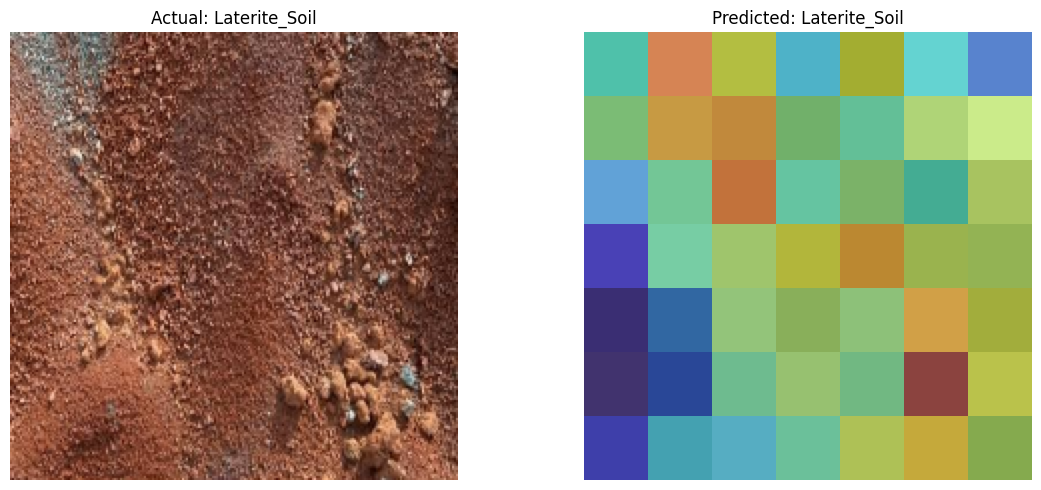

Grad-CAM image saved correctly! ✅


In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.numpy().astype("uint8"))
plt.title(f"Actual: {class_names[true_label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image.numpy().astype("uint8"))
plt.imshow(heatmap.numpy(), cmap="jet", alpha=0.5)
plt.title(f"Predicted: {class_names[int(predicted_label)]}")
plt.axis("off")

plt.tight_layout()

# Save BEFORE showing
plt.savefig(
    "/content/drive/MyDrive/GradCAM_Laterite_Soil.png",
    bbox_inches="tight",
    dpi=150
)

plt.show()

print("Grad-CAM image saved correctly! ✅")

In [31]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "crop_fertilizer_recommendation_dataset.csv":
            print("CSV found at:")
            print(os.path.join(root, file))

## 14. Load Structured Soil and Climate Dataset


In [32]:
import pandas as pd

csv_url = "https://raw.githubusercontent.com/jyothsnabankuru6-cyber/AI-Powered-Soil-Analytics/main/data/raw/crop_fertilizer_recommendation_dataset.csv"

df = pd.read_csv(csv_url)

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully! ✅
Shape: (2200, 13)

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'fertilizer', 'N_status', 'P_status', 'K_status', 'recommendation_note']


## 15. Structured Dataset Validation


In [33]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (2200, 13)

Missing values:
N                      0
P                      0
K                      0
temperature            0
humidity               0
ph                     0
rainfall               0
label                  0
fertilizer             0
N_status               0
P_status               0
K_status               0
recommendation_note    0
dtype: int64

Duplicate rows: 0

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label,fertilizer,N_status,P_status,K_status,recommendation_note
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,DAP (Diammonium Phosphate),Normal,Low,Normal,Based on NPK + climate conditions
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,Balanced NPK (14-14-14),Normal,Normal,Normal,Based on NPK + climate conditions


## 16. Feature and Target Preparation

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]

# Target
y = df['label']

# Encode crop names into numbers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Number of crop classes:", len(label_encoder.classes_))
print("Crop classes:", label_encoder.classes_)

Training data: (1760, 7)
Testing data: (440, 7)
Number of crop classes: 22
Crop classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


## 17. Random Forest Crop Recommendation

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully! ✅")

Random Forest model trained successfully! ✅


## 18. Structured Model Evaluation

In [36]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

Random Forest Accuracy: 0.9954545454545455

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange  

## 19. Structured Model Confusion Matrix


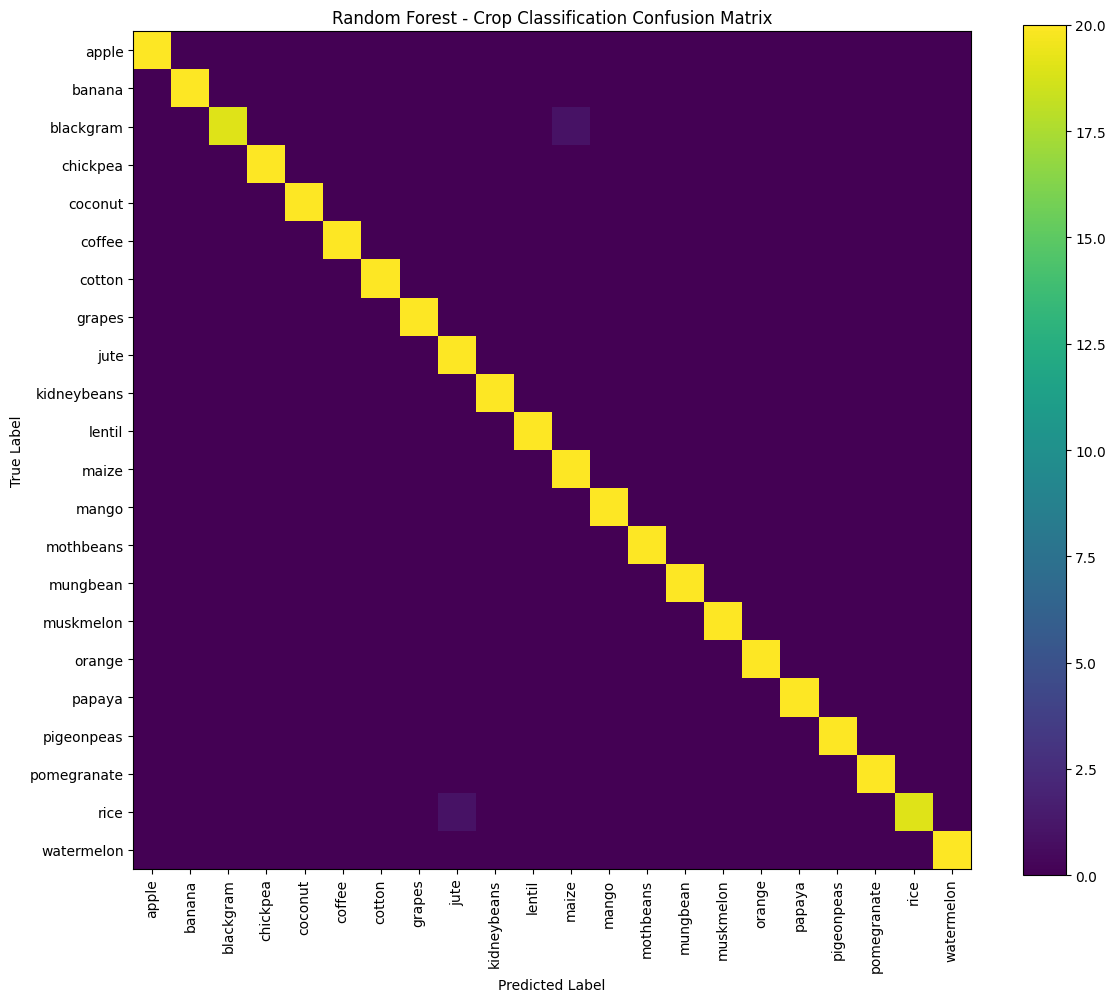

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title("Random Forest - Crop Classification Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=90)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

plt.colorbar()
plt.tight_layout()
plt.show()

## 20. Hybrid Soil and Crop Analysis

In [38]:
def hybrid_prediction(image_path, soil_data):
    """
    Combines soil image classification and structured crop prediction.
    """

    # ---------- Image Prediction ----------
    from tensorflow.keras.utils import load_img, img_to_array

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    image_prediction = model.predict(img_array, verbose=0)
    soil_class = class_names[np.argmax(image_prediction)]

    # ---------- Structured Data Prediction ----------
    structured_input = np.array([[
        soil_data['N'],
        soil_data['P'],
        soil_data['K'],
        soil_data['temperature'],
        soil_data['humidity'],
        soil_data['ph'],
        soil_data['rainfall']
    ]])

    crop_prediction = rf_model.predict(structured_input)[0]
    crop_name = label_encoder.inverse_transform([crop_prediction])[0]

    return soil_class, crop_name

In [39]:
image_path = "/content/drive/MyDrive/Orignal-Dataset/Black_Soil/157a.jpg"

sample = df.iloc[0]

soil_data = {
    'N': sample['N'],
    'P': sample['P'],
    'K': sample['K'],
    'temperature': sample['temperature'],
    'humidity': sample['humidity'],
    'ph': sample['ph'],
    'rainfall': sample['rainfall']
}

soil_result, crop_result = hybrid_prediction(
    image_path,
    soil_data
)

print("🌱 Hybrid Analysis Result")
print("-------------------------")
print("Predicted Soil Type:", soil_result)
print("Recommended Crop:", crop_result)

🌱 Hybrid Analysis Result
-------------------------
Predicted Soil Type: Black_Soil
Recommended Crop: rice


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [40]:
def hybrid_prediction(image_path, soil_data):
    """
    Combines soil image classification and structured crop prediction.
    """

    # ---------- Image Prediction ----------
    from tensorflow.keras.utils import load_img, img_to_array

    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    image_prediction = model.predict(img_array, verbose=0)
    soil_class = class_names[np.argmax(image_prediction)]

    # ---------- Structured Data Prediction ----------
    structured_input = pd.DataFrame([soil_data])

    crop_prediction = rf_model.predict(structured_input)[0]
    crop_name = label_encoder.inverse_transform([crop_prediction])[0]

    return soil_class, crop_name

## 21. Hybrid Prediction Test

In [41]:
image_path = "/content/drive/MyDrive/Orignal-Dataset/Black_Soil/157a.jpg"

sample = df.iloc[0]

soil_data = {
    'N': sample['N'],
    'P': sample['P'],
    'K': sample['K'],
    'temperature': sample['temperature'],
    'humidity': sample['humidity'],
    'ph': sample['ph'],
    'rainfall': sample['rainfall']
}

soil_result, crop_result = hybrid_prediction(
    image_path,
    soil_data
)

print("🌱 Hybrid Analysis Result")
print("-------------------------")
print("Predicted Soil Type:", soil_result)
print("Recommended Crop:", crop_result)

🌱 Hybrid Analysis Result
-------------------------
Predicted Soil Type: Black_Soil
Recommended Crop: rice


## 22. Final Results

In [42]:
print("🌱 AI-POWERED SOIL ANALYTICS - FINAL RESULTS")
print("=" * 50)

print("\n🖼️ Soil Image Classification")
print("Model: ResNet50 Transfer Learning")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\n🌾 Structured Crop Recommendation")
print("Model: Random Forest")
print(f"Test Accuracy: {rf_accuracy * 100:.2f}%")

print("\n🔗 Hybrid Analysis")
print("Soil Type:", soil_result)
print("Recommended Crop:", crop_result)

print("\n🔍 Explainability")
print("Method: Grad-CAM")
print("Last Convolutional Layer: conv5_block3_out")

🌱 AI-POWERED SOIL ANALYTICS - FINAL RESULTS

🖼️ Soil Image Classification
Model: ResNet50 Transfer Learning
Test Accuracy: 81.71%

🌾 Structured Crop Recommendation
Model: Random Forest
Test Accuracy: 99.55%

🔗 Hybrid Analysis
Soil Type: Black_Soil
Recommended Crop: rice

🔍 Explainability
Method: Grad-CAM
Last Convolutional Layer: conv5_block3_out


## Milestone 2 Conclusion

The AI-Powered Soil Analytics system combines soil image classification with structured soil and climate data.

### Key Results
- ResNet50 Transfer Learning achieved **81.71% test accuracy** for soil classification.
- Random Forest achieved **99.55% test accuracy** for crop recommendation.
- Grad-CAM was used to provide visual explainability for the soil image predictions.
- Hybrid analysis combines the predicted soil type with structured soil and climate information to provide a crop recommendation.

### Outcome
The developed system demonstrates how computer vision and structured machine learning can be combined to support soil analysis and crop management.